# Problem 3 – Gradient Descent on a Two-Parameter Cost Function

$$f(t_1,t_2)=\dfrac{1}{3^{-t_1^2-t_2^2}+1}$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import log

In [2]:
# Cost function
def f(t1, t2):
    return 1 / (3**(-t1**2 - t2**2) + 1)

# Partial derivatives
def pdfx(t1, t2):
    return 2*t1*log(3)*(3**(-t1**2-t2**2)) / (3**(-t1**2-t2**2)+1)**2

def pdfy(t1, t2):
    return 2*t2*log(3)*(3**(-t1**2-t2**2)) / (3**(-t1**2-t2**2)+1)**2

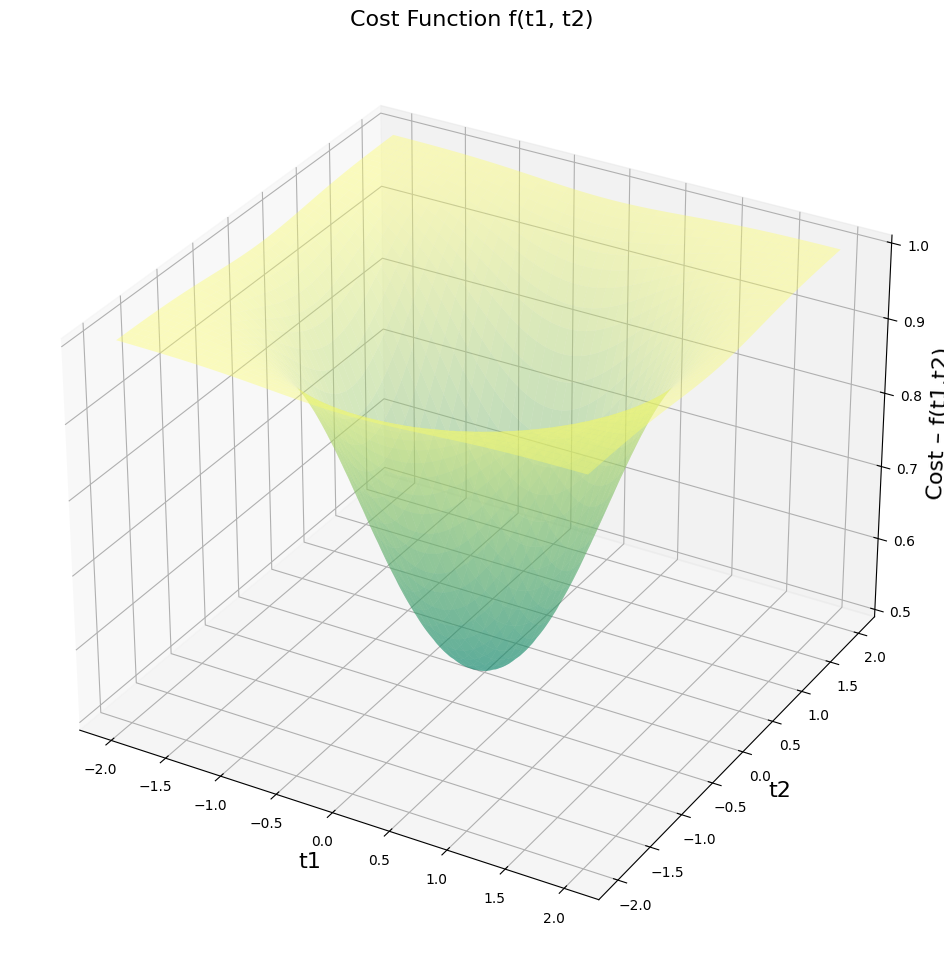

In [3]:
t1 = np.linspace(-2, 2, 200)
t2 = np.linspace(-2, 2, 200)
t1, t2 = np.meshgrid(t1, t2)

fig = plt.figure(figsize=[16, 12])
ax  = plt.axes(projection='3d')
ax.set_xlabel('t1', fontsize=16)
ax.set_ylabel('t2', fontsize=16)
ax.set_zlabel('Cost – f(t1,t2)', fontsize=16)
ax.plot_surface(t1, t2, f(t1, t2), alpha=0.4, cmap='summer')
plt.title('Cost Function f(t1, t2)', fontsize=16)
plt.show()

---
## Part (a) – Run gradient descent and report iteration count & final cost

The original loop is run **as-is** (`max_iter = 20 000`, no early-stop). After it finishes we print the total iterations and `f(t1_new, t2_new)`.

In [4]:
# ── Hyperparameters ──────────────────────────────────────────────────
learning_rate = 0.1
max_iter      = 20000
initial_t1    = 1.8
initial_t2    = 1.5
precision     = 0.000001

# ── Original gradient descent loop (no termination condition) ─────────
t1_old, t2_old = initial_t1, initial_t2
t1_list, t2_list = [], []

for i in range(1, max_iter + 1):
    t1_new = t1_old - learning_rate * pdfx(t1_old, t2_old)
    t2_new = t2_old - learning_rate * pdfy(t1_old, t2_old)
    t1_list.append(t1_old)
    t2_list.append(t2_old)
    t1_old = t1_new
    t2_old = t2_new

# ── Part (a): Print results ───────────────────────────────────────────
print('=' * 52)
print('  Part (a): Results after gradient descent')
print('=' * 52)
print(f'  Number of iterations   : {i}')
print(f'  Final t1_new           : {t1_new}')
print(f'  Final t2_new           : {t2_new}')
print(f'  Cost  f(t1_new,t2_new) : {f(t1_new, t2_new)}')
print('=' * 52)

  Part (a): Results after gradient descent
  Number of iterations   : 20000
  Final t1_new           : 4e-323
  Final t2_new           : 4e-323
  Cost  f(t1_new,t2_new) : 0.5


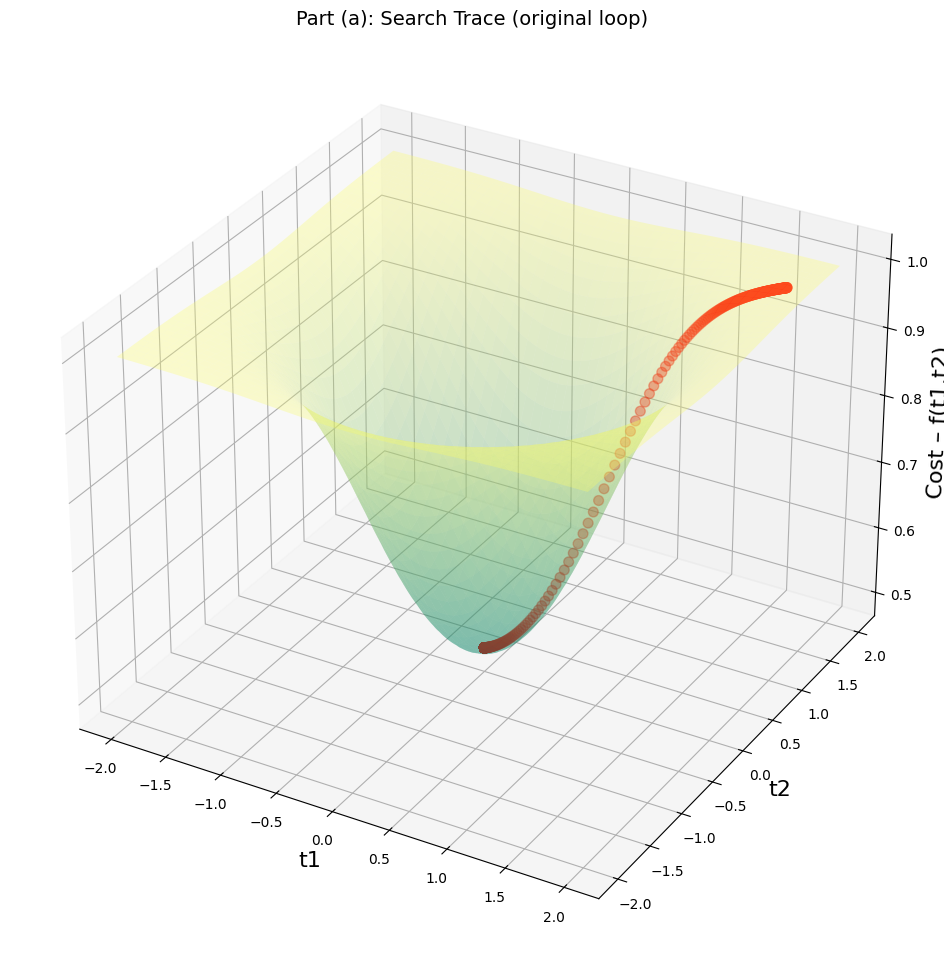

In [5]:
fig = plt.figure(figsize=[16, 12])
ax  = plt.axes(projection='3d')
ax.set_xlabel('t1', fontsize=16)
ax.set_ylabel('t2', fontsize=16)
ax.set_zlabel('Cost – f(t1,t2)', fontsize=16)
ax.set_title('Part (a): Search Trace (original loop)', fontsize=14)
ax.plot_surface(t1, t2, f(t1, t2), alpha=0.3, cmap='summer')
t1_arr = np.array(t1_list)
t2_arr = np.array(t2_list)
ax.scatter(t1_arr, t2_arr, f(t1_arr, t2_arr), alpha=0.4, s=50, color='red')
plt.show()

---
## Part (b) – Has the algorithm converged?

**Short answer: The algorithm has converged — but only because it ran all 20 000 iterations.**

### What the numbers tell us

| Quantity | Value | Interpretation |
|---|---|---|
| Final cost `f(t1,t2)` | **0.5** | Equals `f(0,0)` — the true global minimum |
| `t1_new`, `t2_new` | ≈ 4 × 10⁻³²³ | Float underflow — parameters are effectively **0** |
| Loop counter `i` | **20 000** | Ran **every** iteration — no early exit |

The minimum is `f(0,0) = 1/(3⁰+1) = 0.5`, so the cost is correct.
However, the algorithm **did not know it had converged** — it kept running all
20 000 iterations needlessly.

### Why an algorithm might fail to converge (or converge slowly)

1. **No termination condition** – the loop runs to `max_iter` regardless; wastes computation after convergence.
2. **`max_iter` too small** – if the budget runs out before the parameters settle, the result is wherever the algorithm stopped, not the true minimum.
3. **Learning rate too large** – parameters overshoot the minimum each step and the cost *increases* or oscillates.
4. **Learning rate too small** – each step is tiny; far more iterations are needed to reach the minimum.
5. **Flat gradient near the minimum** – the gradient (and therefore each update) shrinks to near-zero; progress crawls even though the algorithm has not yet reached the bottom.

### Conclusion
The 20 000-iteration budget happened to be enough here, but the approach is **inefficient**. Part (c) shows both remedies.

---
## Part (c) – Fixes

### Fix 1 – Increase `max_iter`
Raise the budget to **100 000** so the algorithm has enough room to converge for a wider range of starting points and learning rates.

### Fix 2 – Insert a termination condition
Break early when the total parameter update is negligible:

$$\text{step\_size} = |t1_{\text{new}} - t1_{\text{old}}| + |t2_{\text{new}} - t2_{\text{old}}| \leq \text{precision}$$

This is the standard stopping criterion for gradient descent.

### Fix 1 – Increased number of iterations (`max_iter = 100 000`)

In [6]:
# ── Fix 1: larger iteration budget ──────────────────────────────────
learning_rate = 0.1
max_iter      = 100000          # increased from 20 000
initial_t1    = 1.8
initial_t2    = 1.5
precision     = 0.000001

t1_old, t2_old = initial_t1, initial_t2
t1_list1, t2_list1 = [], []

for i in range(1, max_iter + 1):
    t1_new = t1_old - learning_rate * pdfx(t1_old, t2_old)
    t2_new = t2_old - learning_rate * pdfy(t1_old, t2_old)
    t1_list1.append(t1_old)
    t2_list1.append(t2_old)
    t1_old = t1_new
    t2_old = t2_new

print('=' * 52)
print('  Fix 1: max_iter raised to 100 000')
print('=' * 52)
print(f'  Number of iterations   : {i}')
print(f'  Final t1_new           : {t1_new:.10f}')
print(f'  Final t2_new           : {t2_new:.10f}')
print(f'  Cost  f(t1_new,t2_new) : {f(t1_new, t2_new):.10f}')
print('=' * 52)

  Fix 1: max_iter raised to 100 000
  Number of iterations   : 100000
  Final t1_new           : 0.0000000000
  Final t2_new           : 0.0000000000
  Cost  f(t1_new,t2_new) : 0.5000000000


### Fix 2 – Termination condition added

In [7]:
# ── Fix 2: early stopping when step size <= precision ───────────────
learning_rate = 0.1
max_iter      = 100000
initial_t1    = 1.8
initial_t2    = 1.5
precision     = 0.000001

t1_old, t2_old = initial_t1, initial_t2
t1_list2, t2_list2 = [], []
converged = False

for i in range(1, max_iter + 1):
    t1_new = t1_old - learning_rate * pdfx(t1_old, t2_old)
    t2_new = t2_old - learning_rate * pdfy(t1_old, t2_old)

    t1_list2.append(t1_old)
    t2_list2.append(t2_old)

    # ── Termination condition ──────────────────────────────────────────
    step_size = abs(t1_new - t1_old) + abs(t2_new - t2_old)
    if step_size <= precision:
        t1_old, t2_old = t1_new, t2_new
        converged = True
        break

    t1_old = t1_new
    t2_old = t2_new

print('=' * 52)
print('  Fix 2: termination condition inserted')
print('=' * 52)
print(f'  Converged early        : {converged}')
print(f'  Number of iterations   : {i}  (out of {max_iter})')
print(f'  Iterations saved       : {max_iter - i}')
print(f'  Final t1_new           : {t1_new:.10f}')
print(f'  Final t2_new           : {t2_new:.10f}')
print(f'  Cost  f(t1_new,t2_new) : {f(t1_new, t2_new):.10f}')
print('=' * 52)

  Fix 2: termination condition inserted
  Converged early        : True
  Number of iterations   : 408  (out of 100000)
  Iterations saved       : 99592
  Final t1_new           : 0.0000090581
  Final t2_new           : 0.0000075484
  Cost  f(t1_new,t2_new) : 0.5000000000


### Visualisation: search traces for Fix 1 vs Fix 2

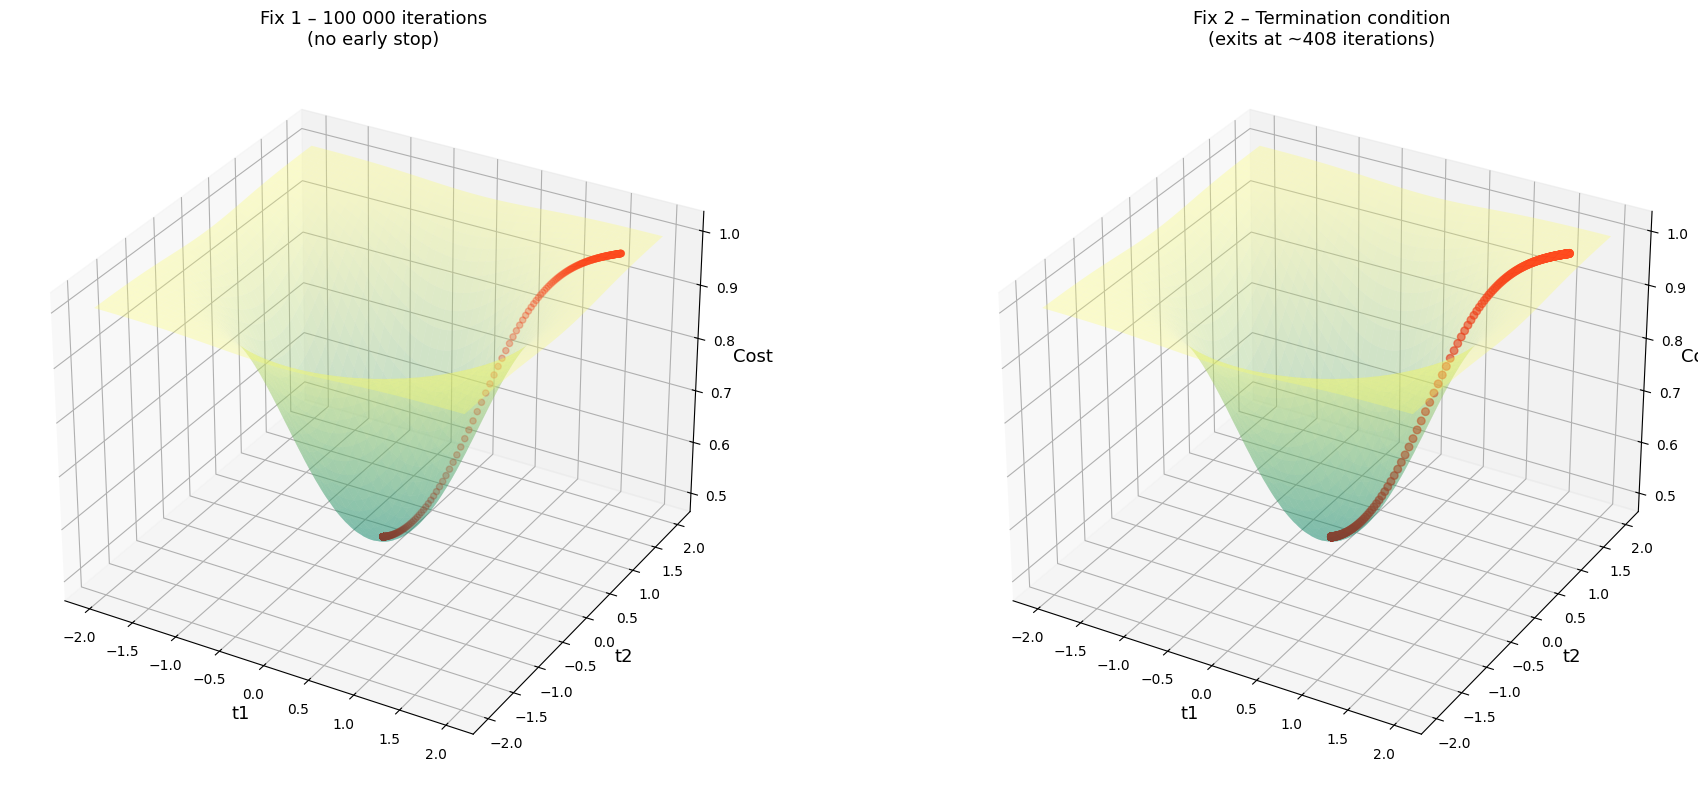

In [8]:
fig = plt.figure(figsize=[20, 8])

# Fix 1 trace
ax1 = fig.add_subplot(121, projection='3d')
ax1.set_xlabel('t1', fontsize=13)
ax1.set_ylabel('t2', fontsize=13)
ax1.set_zlabel('Cost', fontsize=13)
ax1.set_title('Fix 1 – 100 000 iterations\n(no early stop)', fontsize=13)
ax1.plot_surface(t1, t2, f(t1, t2), alpha=0.3, cmap='summer')
t1_a1 = np.array(t1_list1)
t2_a1 = np.array(t2_list1)
ax1.scatter(t1_a1, t2_a1, f(t1_a1, t2_a1), alpha=0.3, s=20, color='red')

# Fix 2 trace
ax2 = fig.add_subplot(122, projection='3d')
ax2.set_xlabel('t1', fontsize=13)
ax2.set_ylabel('t2', fontsize=13)
ax2.set_zlabel('Cost', fontsize=13)
ax2.set_title('Fix 2 – Termination condition\n(exits at ~408 iterations)', fontsize=13)
ax2.plot_surface(t1, t2, f(t1, t2), alpha=0.3, cmap='summer')
t1_a2 = np.array(t1_list2)
t2_a2 = np.array(t2_list2)
ax2.scatter(t1_a2, t2_a2, f(t1_a2, t2_a2), alpha=0.6, s=30, color='red')

plt.tight_layout()
plt.show()

---
## Summary

| | Original | Fix 1 | Fix 2 |
|---|---|---|---|
| `max_iter` | 20 000 | 100 000 | 100 000 |
| Termination condition | ❌ | ❌ | ✅ |
| Iterations actually used | 20 000 | 100 000 | **~408** |
| Final cost | 0.5 | 0.5 | 0.5 |
| Efficient? | ❌ | ❌ | ✅ |

**Fix 2** is the correct engineering practice: combine a generous `max_iter` (safety net) with an early-stop condition (efficiency). The same minimum is reached in ~408 iterations instead of 100 000.